## Dataset loading and analysis

In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

I0000 00:00:1777295103.781957   27492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777295103.782495   27492 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777295103.839511   27492 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777295105.329878   27492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
import matplotlib.pyplot as plt

In [3]:
(X_train,Y_train),(X_test,Y_test) = keras.datasets.mnist.load_data()    
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape
# 3D array
# 60k images of 28*28 pixels

(10000, 28, 28)

In [5]:
X_train[0].shape

(28, 28)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

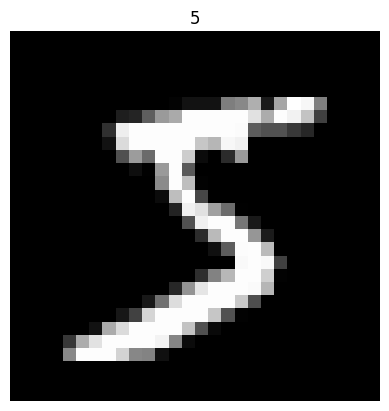

In [6]:
plt.imshow(X_train[0], cmap='gray')
plt.title(Y_train[0])
plt.axis('off')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

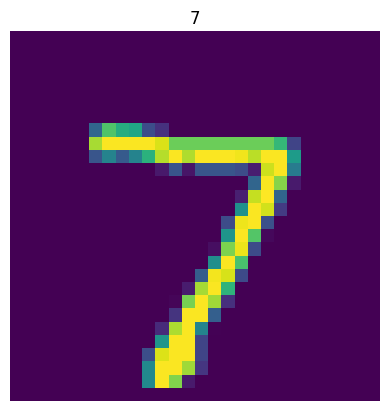

In [7]:
plt.imshow(X_test[0])
plt.title(Y_test[0])
plt.axis('off')


## preprocessing

In [8]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

## ANN

In [10]:
model = Sequential([
    Flatten(input_shape=(28,28)), # convert heigher dimention input into 1D
    Dense(300, activation='relu'),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')])

E0000 00:00:1777295334.924360   27492 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [12]:
history = model.fit(X_train_scaled,Y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9321 - loss: 0.2254 - val_accuracy: 0.9652 - val_loss: 0.1151
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9716 - loss: 0.0905 - val_accuracy: 0.9684 - val_loss: 0.1010
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9808 - loss: 0.0604 - val_accuracy: 0.9737 - val_loss: 0.0916
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9852 - loss: 0.0467 - val_accuracy: 0.9728 - val_loss: 0.0938
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9886 - loss: 0.0347 - val_accuracy: 0.9709 - val_loss: 0.1066


In [13]:
model.save('mnist_model.keras')

## prediction

In [14]:
Y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [15]:
Y_prob

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10), dtype=float32)

In [16]:
Y_prob = Y_prob.argmax(axis=1) # row wise max probability for each of the prediction out of 10 probability

In [17]:
Y_prob

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
accuracy_score(Y_prob,Y_test)

0.9759

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

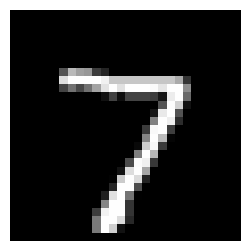

In [31]:
plt.figure(figsize=(3,3))
plt.imshow(X_test[0], cmap='grey')
plt.axis('off')

In [34]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([7])

## Graphs

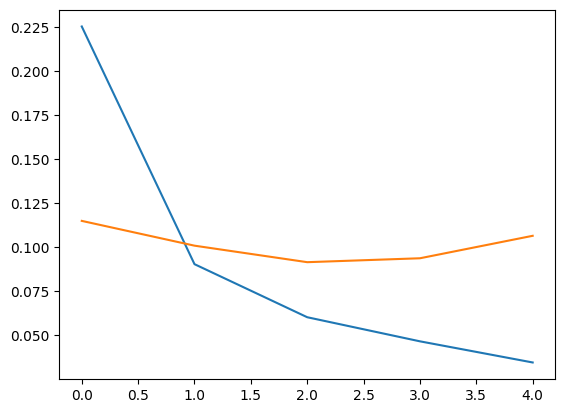

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

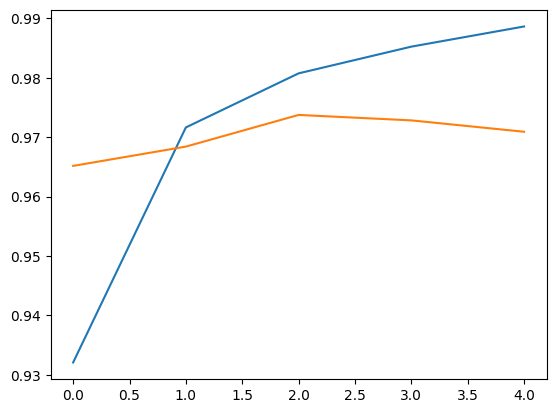

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])